In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/rhome/sawale/indus_traning/mlm-fine-tuning/mlm')

In [3]:
import os
import json
import random
import numpy as np
from transformers import AutoModel, AutoTokenizer, pipeline
import torch
import torch.nn.functional as F
from dotenv import load_dotenv
load_dotenv()
from huggingface_hub import login
login(os.getenv("HUGGINGFACE_TOKEN"))

from preprocess_data import get_dataset


def set_seed(seed=42) -> None:
    """Set all seeds to make results reproducible (deterministic mode).
    When seed is a false-y value or not supplied, disables deterministic mode."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

/rhome/sawale/indus_traning/mlm-fine-tuning/env39/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/rhome/sawale/indus_traning/mlm-fine-tuning/env39/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


# Load dataset

In [4]:
import wandb
run = wandb.init()
artifact = run.use_artifact('nasa-impact/science-keywords-recommender/df_train:v51', type='dataset')
train_data_path = artifact.download()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: sajil (nasa-impact) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb:   1 of 1 files downloaded.  


In [5]:
import pandas as pd
df = pd.read_parquet(train_data_path)
print(df.shape)
df.head()


(4435, 2)


,concept_id,text
0,C2244291405-AMD_KOPRI,Genome analysis of the Antarctic Pseudomonas p...
1,C2244291406-AMD_KOPRI,Atmospheric and oceanic nitrous oxide in the m...
2,C2244291412-AMD_KOPRI,Soil samples near Cambridge Bay of Canada in 2...
3,C2244291447-AMD_KOPRI,Atmospheric and oceanic carbon monoxide in the...
4,C2244291450-AMD_KOPRI,Korean Antarctic survey was conducted in north...


In [6]:
train_data_path

'/nas/rhome/sawale/indus_traning/mlm-fine-tuning/mlm/embedding_analysis/artifacts/df_train:v51'

In [7]:
from datasets import Dataset, DatasetDict, load_dataset
dataset = load_dataset("parquet", data_files = train_data_path + "/*")
dataset

Generating train split: 4435 examples [00:00, 199113.05 examples/s]


DatasetDict({
    train: Dataset({
        features: ['concept_id', 'text'],
        num_rows: 4435
    })
})

# Load the model and tokenizer

In [10]:
# Load model or dataset
new_model_name = "/rhome/sawale/indus_traning/science-keywords-classification/modelling/checkpoints/INDUS_extended_500K_SDE"
old_model_name = "nasa-impact/nasa-smd-ibm-v0.1"

# Step 1: Load the model and tokenizer
model_names = {"Original_INDUS": old_model_name, "INDUS_context_extended": new_model_name}
models = {mn:AutoModel.from_pretrained(hf_model_name) for mn, hf_model_name in model_names.items()}
tokenizers = {mn:AutoTokenizer.from_pretrained(hf_model_name) for mn, hf_model_name in model_names.items()}
embeddings = {mn:None for mn in model_names.keys()}

Some weights of RobertaModel were not initialized from the model checkpoint at nasa-impact/nasa-smd-ibm-v0.1 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at /rhome/sawale/indus_traning/science-keywords-classification/modelling/checkpoints/INDUS_extended_500K_SDE and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [11]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move models to GPU
for mn, model in models.items():
    model.to(device)

# Generate embeddings

In [10]:
from tqdm import tqdm

batch_size = 16  # Adjust based on GPU memory

# Iterate through the dataset in batches
with torch.no_grad():
    for i in tqdm(range(0, len(dataset["train"]), batch_size)):
        # Extract a batch from the dataset by slicing
        batch = dataset["train"][i:i + batch_size]

        # Generate embeddings for each model
        for mn, model in models.items():
            inputs = tokenizers.get(mn)(
                batch["text"],  # Assuming the dataset has a "text" column
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=500
            )

            # Move inputs to the same device as the model
            inputs = {key: val.to(device) for key, val in inputs.items()}
            
            output = model(**inputs)
            # get the last hidden state and aggregrate the embedding per example
            emb = output.last_hidden_state.mean(dim=1, keepdim=False)
            if embeddings.get(mn) is None:
                embeddings[mn] = emb.cpu()
            else:
                embeddings[mn] = torch.cat((embeddings[mn], emb.cpu()), dim=0)
        
torch.save(embeddings, 'model_embeddings.pt')

100%|██████████| 278/278 [07:51<00:00,  1.70s/it]


In [12]:
# load the embedding if there is embedding file
# check if the file exists first
path = 'model_embeddings.pt'
if os.path.exists(path):
    embeddings = torch.load(path)

In [13]:
embeddings

{'Original_INDUS': tensor([[-0.0819,  0.3139,  0.0743,  ..., -0.2278,  0.0740,  0.0608],
         [-0.1879,  0.2654, -0.1508,  ..., -0.1266,  0.0246, -0.1300],
         [-0.1443,  0.1012,  0.2963,  ..., -0.1696, -0.0172, -0.0021],
         ...,
         [-0.2446, -0.0867, -0.0603,  ..., -0.0041,  0.0896, -0.1058],
         [-0.3599, -0.1626, -0.0328,  ...,  0.1122,  0.1119, -0.2268],
         [-0.2371,  0.0489, -0.0589,  ...,  0.0638,  0.2026, -0.1307]]),
 'INDUS_context_extended': tensor([[-0.1359,  0.1500, -0.1559,  ..., -0.0025,  0.0331,  0.2103],
         [-0.0537,  0.3253, -0.1682,  ..., -0.1872,  0.0151, -0.0929],
         [ 0.1113, -0.1544,  0.1915,  ...,  0.3204, -0.1470, -0.1218],
         ...,
         [-0.1673, -0.0520, -0.0869,  ..., -0.1278,  0.1667, -0.0801],
         [-0.2165, -0.2680, -0.0314,  ..., -0.0607,  0.3162, -0.1181],
         [-0.0944,  0.0939, -0.0419,  ..., -0.3372,  0.2832,  0.0504]])}

# Generate the difference between the embeddings

In [14]:
embedding_difference = embeddings["INDUS_context_extended"] - embeddings["Original_INDUS"]

print(embedding_difference.shape)

torch.Size([4435, 768])


# Use UMAP to reduce the dimensionality of the embeddings

/rhome/sawale/indus_traning/mlm-fine-tuning/env39/lib64/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/rhome/sawale/indus_traning/mlm-fine-tuning/env39/lib64/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/rhome/sawale/indus_traning/mlm-fine-tuning/env39/lib64/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


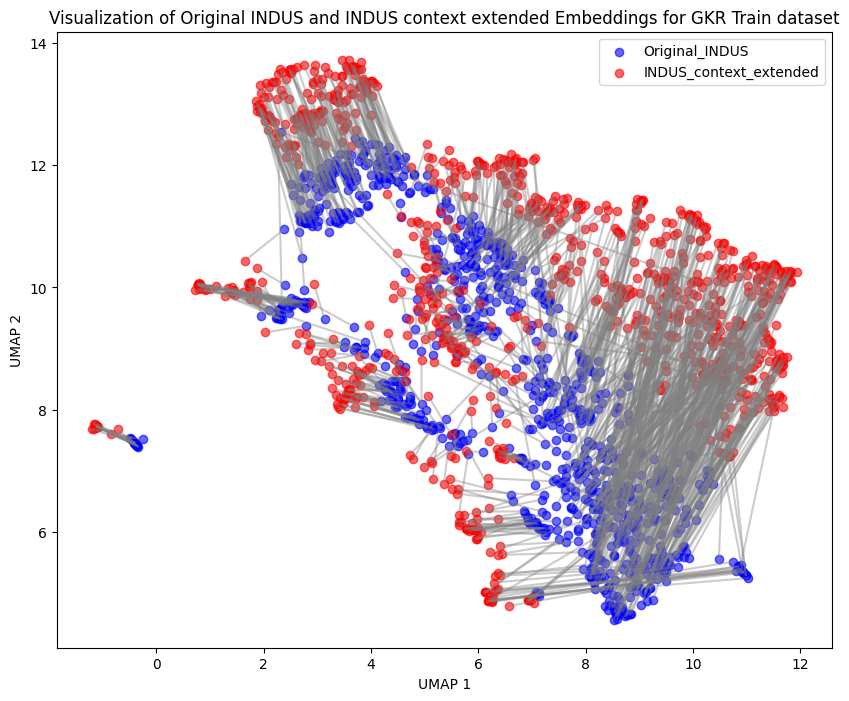

In [16]:
import torch
import umap
import matplotlib.pyplot as plt
import numpy as np
# Set the random seed


sample_size = 1000

# Initialize UMAP model for dimensionality reduction
umap_model = umap.UMAP(n_components=2)

old_embeddings = embeddings['Original_INDUS'].numpy()[:sample_size]
new_embeddings = embeddings['INDUS_context_extended'].numpy()[:sample_size]

combined_embeddings = np.concatenate((old_embeddings, new_embeddings), axis=0)
umap_model.fit(combined_embeddings)

# Apply UMAP to reduce to 2D
old_embeddings_2d = umap_model.transform(old_embeddings)
new_embeddings_2d = umap_model.transform(new_embeddings)

# Create the plot
plt.figure(figsize=(10, 8))

# Scatter plot for old model embeddings
plt.scatter(old_embeddings_2d[:, 0], old_embeddings_2d[:, 1], c='blue', label='Original_INDUS', alpha=0.6)

# Scatter plot for new model embeddings
plt.scatter(new_embeddings_2d[:, 0], new_embeddings_2d[:, 1], c='red', label='INDUS_context_extended', alpha=0.6)

# Draw lines/arrows from old to new embeddings
for i in range(len(old_embeddings_2d)):
    plt.plot([old_embeddings_2d[i, 0], new_embeddings_2d[i, 0]], 
             [old_embeddings_2d[i, 1], new_embeddings_2d[i, 1]], 
             color='gray', linestyle='-', alpha=0.4)

# Add labels and legend
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('Visualization of Original INDUS and INDUS context extended Embeddings for GKR Train dataset')
plt.legend()

# Show the plot
plt.show()



/rhome/sawale/indus_traning/mlm-fine-tuning/env39/lib64/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/rhome/sawale/indus_traning/mlm-fine-tuning/env39/lib64/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/rhome/sawale/indus_traning/mlm-fine-tuning/env39/lib64/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


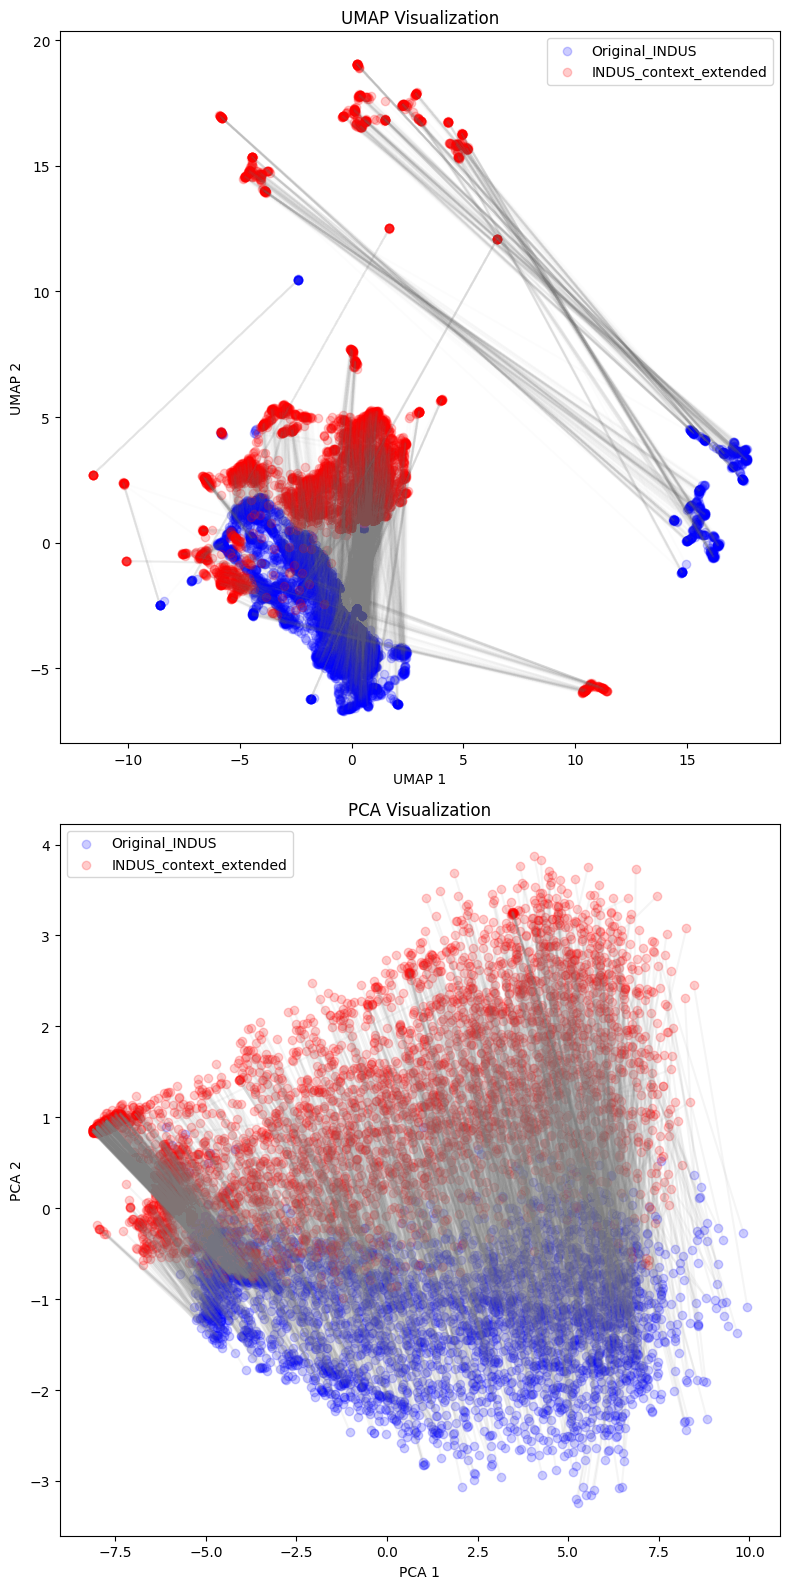

In [21]:
import torch
import umap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Set the random seed for reproducibility
np.random.seed(42)

# Sample size
sample_size = None

# Retrieve embeddings
old_embeddings = embeddings['Original_INDUS'].numpy()[:sample_size]
new_embeddings = embeddings['INDUS_context_extended'].numpy()[:sample_size]

# Combine embeddings for dimensionality reduction
combined_embeddings = np.concatenate((old_embeddings, new_embeddings), axis=0)

# UMAP dimensionality reduction
umap_model = umap.UMAP(n_components=2)
umap_model.fit(combined_embeddings)
old_embeddings_2d_umap = umap_model.transform(old_embeddings)
new_embeddings_2d_umap = umap_model.transform(new_embeddings)

# PCA dimensionality reduction
pca_model = PCA(n_components=2)
pca_model.fit(combined_embeddings)
old_embeddings_2d_pca = pca_model.transform(old_embeddings)
new_embeddings_2d_pca = pca_model.transform(new_embeddings)

# Create side-by-side plots
fig, axes = plt.subplots(2, 1, figsize=(8, 16))

# UMAP Plot
axes[0].scatter(old_embeddings_2d_umap[:, 0], old_embeddings_2d_umap[:, 1], c='blue', label='Original_INDUS', alpha=0.2)
axes[0].scatter(new_embeddings_2d_umap[:, 0], new_embeddings_2d_umap[:, 1], c='red', label='INDUS_context_extended', alpha=0.2)
for i in range(len(old_embeddings_2d_umap)):
    axes[0].plot([old_embeddings_2d_umap[i, 0], new_embeddings_2d_umap[i, 0]], 
                 [old_embeddings_2d_umap[i, 1], new_embeddings_2d_umap[i, 1]], 
                 color='gray', linestyle='-', alpha=0.02)
axes[0].set_title('UMAP Visualization')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].legend()

# PCA Plot
axes[1].scatter(old_embeddings_2d_pca[:, 0], old_embeddings_2d_pca[:, 1], c='blue', label='Original_INDUS', alpha=0.2)
axes[1].scatter(new_embeddings_2d_pca[:, 0], new_embeddings_2d_pca[:, 1], c='red', label='INDUS_context_extended', alpha=0.2)
for i in range(len(old_embeddings_2d_pca)):
    axes[1].plot([old_embeddings_2d_pca[i, 0], new_embeddings_2d_pca[i, 0]], 
                 [old_embeddings_2d_pca[i, 1], new_embeddings_2d_pca[i, 1]], 
                 color='gray', linestyle='-', alpha=0.08)
axes[1].set_title('PCA Visualization')
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')
axes[1].legend()

# Show the plots
plt.tight_layout()
plt.show()


In [18]:
# Find the cosine similarity between the embeddings
cosine_similarity = F.cosine_similarity(embeddings["INDUS_context_extended"], embeddings["Original_INDUS"], dim=1)

In [19]:
# Compute the five-number summary
min_value = torch.min(cosine_similarity)  # Minimum
q1 = torch.quantile(cosine_similarity, 0.25)  # First quartile
median = torch.quantile(cosine_similarity, 0.5)  # Median (Q2)
mean = torch.mean(cosine_similarity)
q3 = torch.quantile(cosine_similarity, 0.75)  # Third quartile
max_value = torch.max(cosine_similarity)  # Maximum
std_value = torch.std(cosine_similarity) 

# Round values to 4 decimal places
min_value = round(min_value.item(), 4)
q1 = round(q1.item(), 4)
median = round(median.item(), 4)
mean = round(mean.item(), 4)
q3 = round(q3.item(), 4)
max_value = round(max_value.item(), 4)
std_value = round(std_value.item(), 4)

# Display the five-number summary
print(f"Minimum: {min_value}")
print(f"First Quartile (Q1): {q1}")
print(f"Median (Q2): {median}")
print(f"Mean: {mean}")
print(f"Third Quartile (Q3): {q3}")
print(f"Maximum: {max_value}")
print(f"Standard Deviation: {std_value}")

Minimum: -0.1514
First Quartile (Q1): 0.8014
Median (Q2): 0.8622
Mean: 0.824
Third Quartile (Q3): 0.8885
Maximum: 0.9562
Standard Deviation: 0.1025


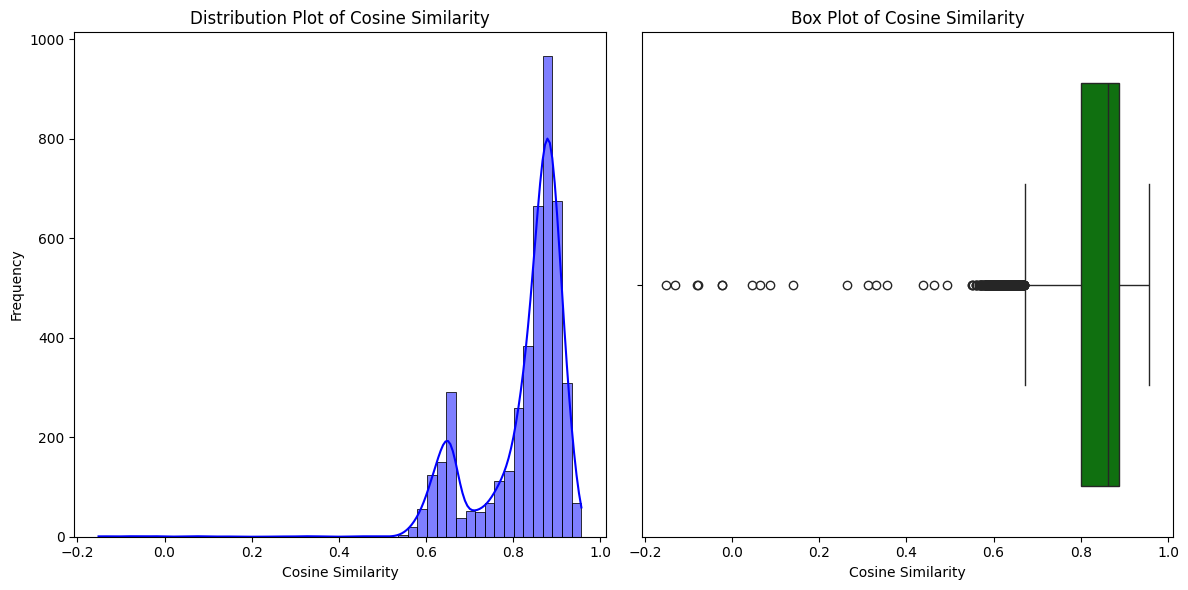

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert data to numpy for compatibility with seaborn/matplotlib
data_np = cosine_similarity.numpy()

# Create the figure and axis
plt.figure(figsize=(12, 6))

# Distribution Plot (Histogram + KDE)
plt.subplot(1, 2, 1)  # First subplot
sns.histplot(data_np, kde=True, color='blue', bins=50)
plt.title("Distribution Plot of Cosine Similarity")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")

# Box Plot
plt.subplot(1, 2, 2)  # Second subplot
sns.boxplot(x=data_np, color='green')
plt.title("Box Plot of Cosine Similarity")
plt.xlabel("Cosine Similarity")

# Display the plots
plt.tight_layout()
plt.show()

In [30]:
12/23.0

0.5217391304347826